In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [ ]:
# load the daily data
pm_all = pd.read_csv("data/pm25_data_complete_2003-2021_nodups_051922.csv")

# Load the locations data
pm_fixed = pd.read_csv('data/pm25_locs_nodups_051922.csv')

/home/vcaristo/miniconda3/envs/patel/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_1_states_provinces_lakes.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/vcaristo/miniconda3/envs/patel/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/home/vcaristo/miniconda3/envs/patel/lib/python3.11/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


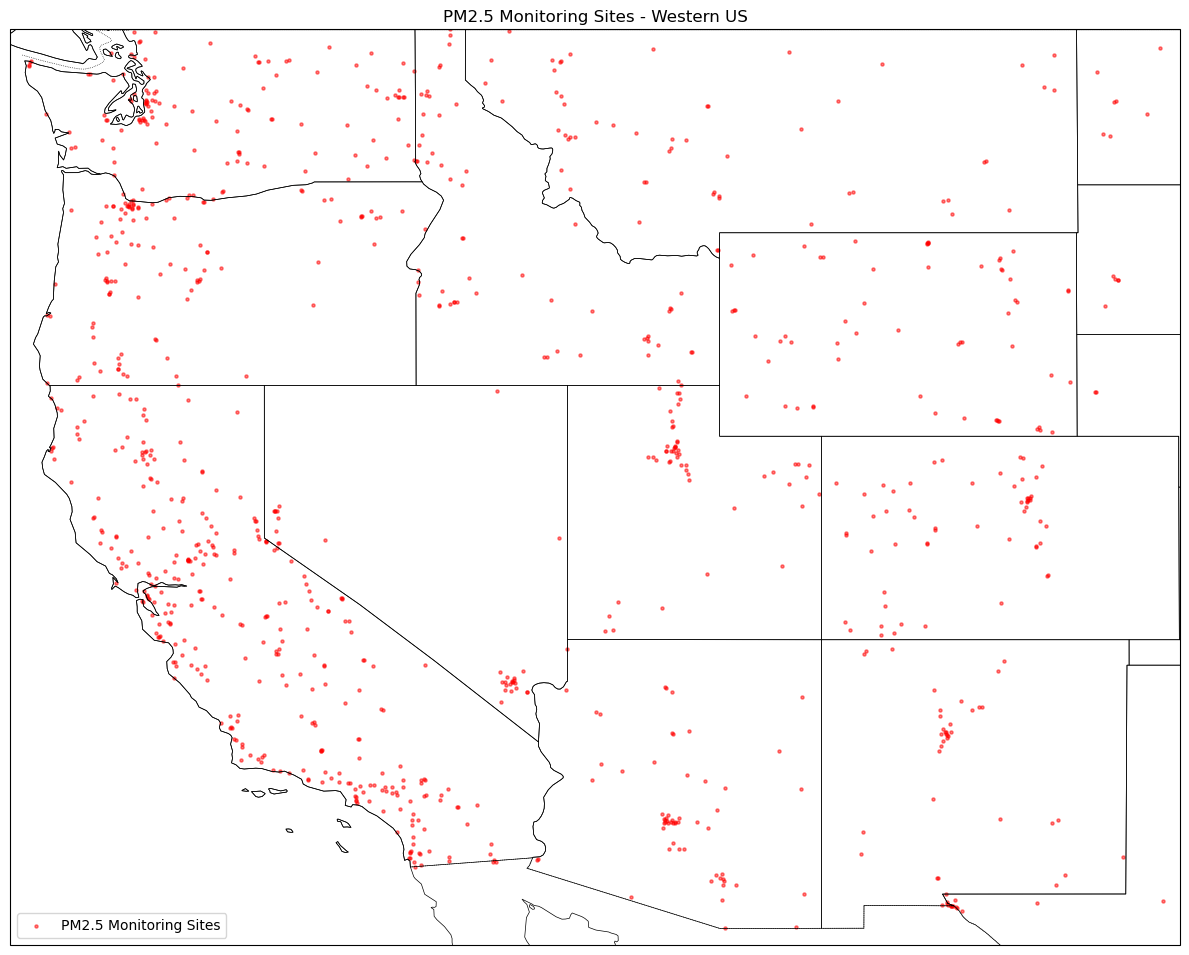

Total points plotted: 975


In [ ]:

# Create the map
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})

# Set extent for western US
ax.set_extent([-125, -102, 31, 49], crs=ccrs.PlateCarree())

# Add state boundaries
ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

# Plot all monitoring points
ax.scatter(pm_fixed['lon'], pm_fixed['lat'], s=5, c='red', alpha=0.5, 
           transform=ccrs.PlateCarree(), label='PM2.5 Monitoring Sites')

ax.set_title('PM2.5 Monitoring Sites - Western US')
ax.legend(loc='lower left')

plt.tight_layout()
plt.show()

print(f"Total points plotted: {len(pm_fixed)}")

In [3]:
pm_all.columns

Index(['id', 'date', 'smogP', 'pm25', 'aot', 'aot_raw', 'cld', 'hgt',
       'longwave', 'rh', 'tmax', 'wind', 'cadI', 'log_pm25', 'cell', 'ID',
       'smogI', 'll_id', 'cluster', 'src', 'n'],
      dtype='object')

In [11]:
pm_fixed.columns[:20].tolist()

['Unnamed: 0',
 'site.id',
 'll_id',
 'cell',
 'lon',
 'lat',
 'cluster',
 'min_d',
 'logpd2500g',
 'geomorphic_protection_index_0p2',
 'minf_700',
 'minf_1000',
 'minf_1500',
 'minf_2500',
 'minf_5000',
 'minf_7500',
 'minf_10000',
 'minf_15000',
 'minf_20000',
 'minf_25000']

In [12]:
# Check a sample of the lat/lon data
pm_fixed[['lat', 'lon']].head(10)

,lat,lon
0,34.058475,-109.441259
1,31.349200,-109.539683
2,32.009410,-109.389060
3,35.206111,-111.652777
4,36.077814,-112.129551
5,35.973117,-111.984846
6,35.140635,-111.969938
7,34.229733,-111.329500
8,33.654700,-111.107400
9,34.090866,-110.942801


In [13]:
# Try using geopandas with US states shapefile
import geopandas as gpd
from shapely.geometry import Point

# Get US states boundaries (natural earth data or census)
# Let's use the built-in dataset from geopandas
try:
    states = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    # Filter to just US states - but this won't have state-level detail
    print("naturalearth_lowres available but doesn't have US states separately")
except:
    print("naturalearth_lowres not available")

naturalearth_lowres not available


In [14]:
# Try using reverse_geocoder library
try:
    import reverse_geocoder as rg
    # Test with a single coordinate
    result = rg.search((34.058475, -109.441259))
    print(result)
except ImportError:
    print("reverse_geocoder not installed")
except Exception as e:
    print(f"Error: {e}")

reverse_geocoder not installed


In [15]:
# Let's download US states shapefile from Census Bureau
import geopandas as gpd

# US Census Bureau states shapefile
states_url = "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_state_20m.zip"

try:
    states = gpd.read_file(states_url)
    print(states[['NAME', 'STUSPS']].head(10))
except Exception as e:
    print(f"Error loading states: {e}")

        NAME STUSPS
0  Louisiana     LA
1     Alaska     AK
2   Maryland     MD
3  Wisconsin     WI
4    Florida     FL
5    Georgia     GA
6  Tennessee     TN
7  Minnesota     MN
8       Iowa     IA
9   Missouri     MO


In [16]:
# Convert pm_fixed to a GeoDataFrame with Point geometry
from shapely.geometry import Point

# Create geometry from lat/lon
geometry = [Point(xy) for xy in zip(pm_fixed['lon'], pm_fixed['lat'])]
pm_gdf = gpd.GeoDataFrame(pm_fixed, geometry=geometry, crs="EPSG:4326")

# Make sure states CRS matches
states = states.to_crs("EPSG:4326")

# Spatial join to get state for each point
pm_with_state = gpd.sjoin(pm_gdf, states[['STUSPS', 'geometry']], how='left', predicate='within')

# Check results
print(pm_with_state['STUSPS'].value_counts())

STUSPS
CA    310
WA    123
OR    102
WY     61
AZ     58
ID     57
CO     57
MT     56
UT     51
NM     40
NV     32
TX     10
ND      7
SD      5
NE      2
Name: count, dtype: int64


In [17]:
# Add the state abbreviation column to pm_fixed
pm_fixed['state'] = pm_with_state['STUSPS'].values

# Verify
print(pm_fixed[['lat', 'lon', 'state']].head(10))
print(f"\nMissing state values: {pm_fixed['state'].isna().sum()}")

         lat         lon state
0  34.058475 -109.441259    AZ
1  31.349200 -109.539683    AZ
2  32.009410 -109.389060    AZ
3  35.206111 -111.652777    AZ
4  36.077814 -112.129551    AZ
5  35.973117 -111.984846    AZ
6  35.140635 -111.969938    AZ
7  34.229733 -111.329500    AZ
8  33.654700 -111.107400    AZ
9  34.090866 -110.942801    AZ

Missing state values: 4


In [18]:
# Check which points don't have a state
missing = pm_fixed[pm_fixed['state'].isna()][['lat', 'lon']]
print("Points without state assignment:")
print(missing)

Points without state assignment:
           lat         lon
471  48.371820 -124.595190
769  31.758532 -106.501045
775  32.629225 -115.447769
778  32.633671 -115.504995


In [19]:
# These might be at edges. Let's try using 'nearest' join for the missing ones
# or manually assign based on location

# Looking at the coordinates:
# 48.37, -124.59 - Cape Flattery area, should be WA
# 31.76, -106.50 - El Paso area, should be TX  
# 32.63, -115.45 and -115.50 - Imperial County area, should be CA

# Let's manually fix these based on their approximate locations
pm_fixed.loc[471, 'state'] = 'WA'  # Cape Flattery
pm_fixed.loc[769, 'state'] = 'TX'  # El Paso
pm_fixed.loc[775, 'state'] = 'CA'  # Imperial County
pm_fixed.loc[778, 'state'] = 'CA'  # Imperial County

print("Fixed missing states:")
print(pm_fixed.loc[[471, 769, 775, 778], ['lat', 'lon', 'state']])
print(f"\nMissing state values: {pm_fixed['state'].isna().sum()}")

Fixed missing states:
           lat         lon state
471  48.371820 -124.595190    WA
769  31.758532 -106.501045    TX
775  32.629225 -115.447769    CA
778  32.633671 -115.504995    CA

Missing state values: 0


In [21]:
pm_fixed.to_csv('pm25_locs_with_states.csv', index=False)

In [23]:
# Check the lat/lon ranges to confirm CRS
print("Latitude range:", pm_fixed['lat'].min(), "to", pm_fixed['lat'].max())
print("Longitude range:", pm_fixed['lon'].min(), "to", pm_fixed['lon'].max())

Latitude range: 31.3373024001677 to 48.998333
Longitude range: -124.62491 to -102.3347505


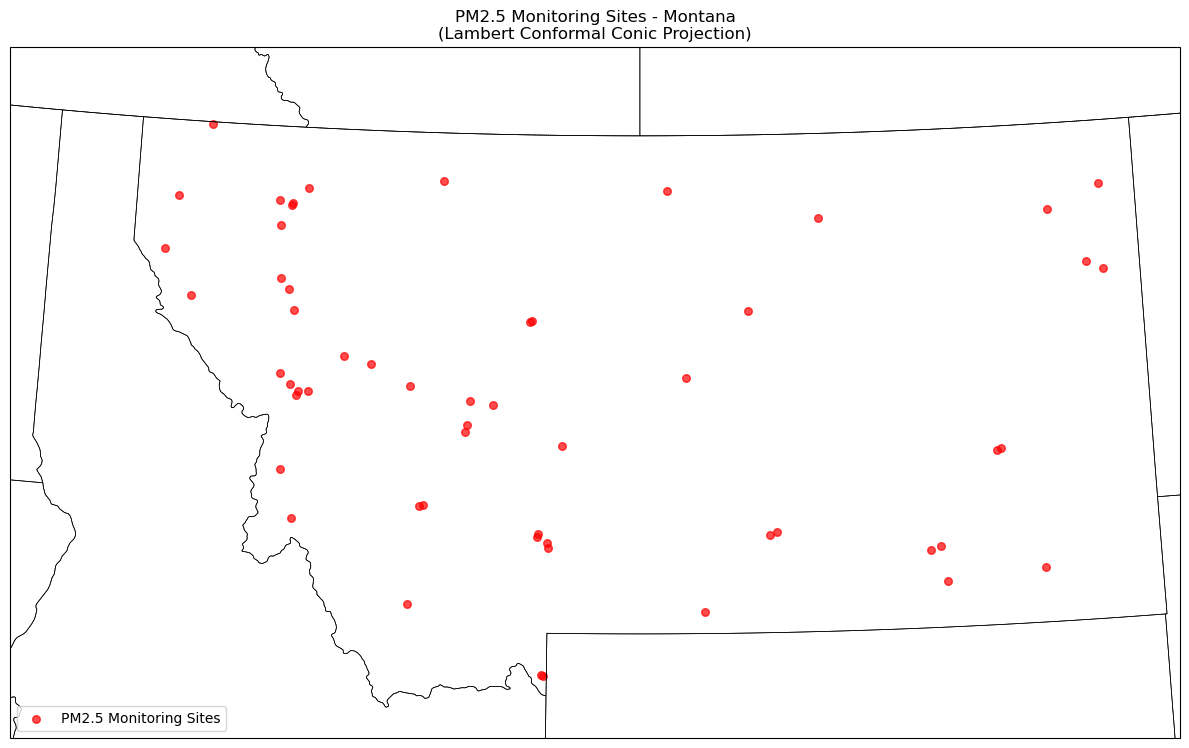

In [30]:
# Create Montana map with Lambert Conformal Conic projection
fig, ax = plt.subplots(figsize=(12, 8), 
                       subplot_kw={'projection': ccrs.LambertConformal(
                           central_longitude=-110, 
                           central_latitude=47,
                           standard_parallels=(45, 49))})

# Set extent for Montana (need to specify the CRS of the extent coordinates)
ax.set_extent([-117, -104, 44, 49.5], crs=ccrs.PlateCarree())

# Add state boundaries
ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

# Plot Montana monitoring points
ax.scatter(pm_mt['lon'], pm_mt['lat'], s=30, c='red', alpha=0.7, 
           transform=ccrs.PlateCarree(), label='PM2.5 Monitoring Sites')

ax.set_title('PM2.5 Monitoring Sites - Montana\n(Lambert Conformal Conic Projection)')
ax.legend(loc='lower left')

plt.tight_layout()
plt.show()

## What is the distribution of data in pm_all?

In [27]:
# First check what the date column looks like in pm_all
print("Date column sample:")
print(pm_all['date'].head(10))
print(f"\nDate range: {pm_all['date'].min()} to {pm_all['date'].max()}")

Date column sample:
0    20030101
1    20030101
2    20030101
3    20030101
4    20030101
5    20030101
6    20030101
7    20030101
8    20030101
9    20030101
Name: date, dtype: int64

Date range: 20030101 to 20220106


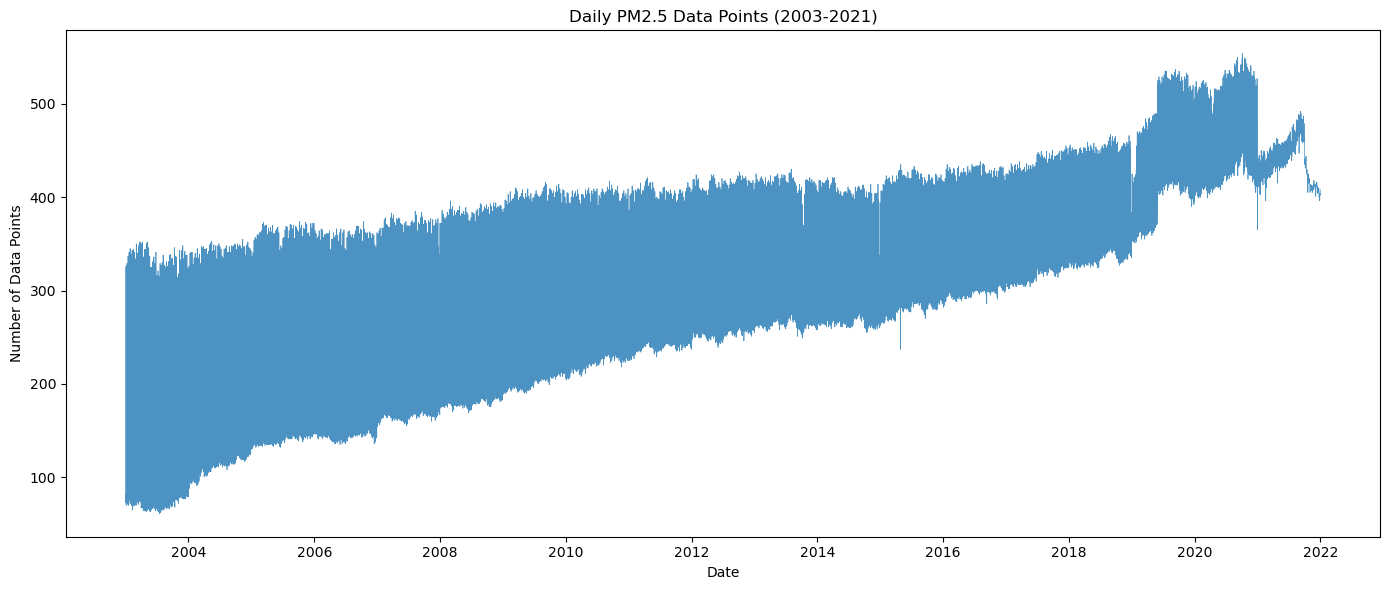

Total days: 6940
Avg points per day: 299.0


In [28]:
# Convert date to datetime and count points per day
pm_all['date_dt'] = pd.to_datetime(pm_all['date'], format='%Y%m%d')

# Filter to 2003-2021
pm_filtered = pm_all[(pm_all['date_dt'] >= '2003-01-01') & (pm_all['date_dt'] <= '2021-12-31')]

# Count data points per day
daily_counts = pm_filtered.groupby('date_dt').size()

# Create line plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily_counts.index, daily_counts.values, linewidth=0.5, alpha=0.8)

ax.set_xlabel('Date')
ax.set_ylabel('Number of Data Points')
ax.set_title('Daily PM2.5 Data Points (2003-2021)')

plt.tight_layout()
plt.show()

print(f"Total days: {len(daily_counts)}")
print(f"Avg points per day: {daily_counts.mean():.1f}")

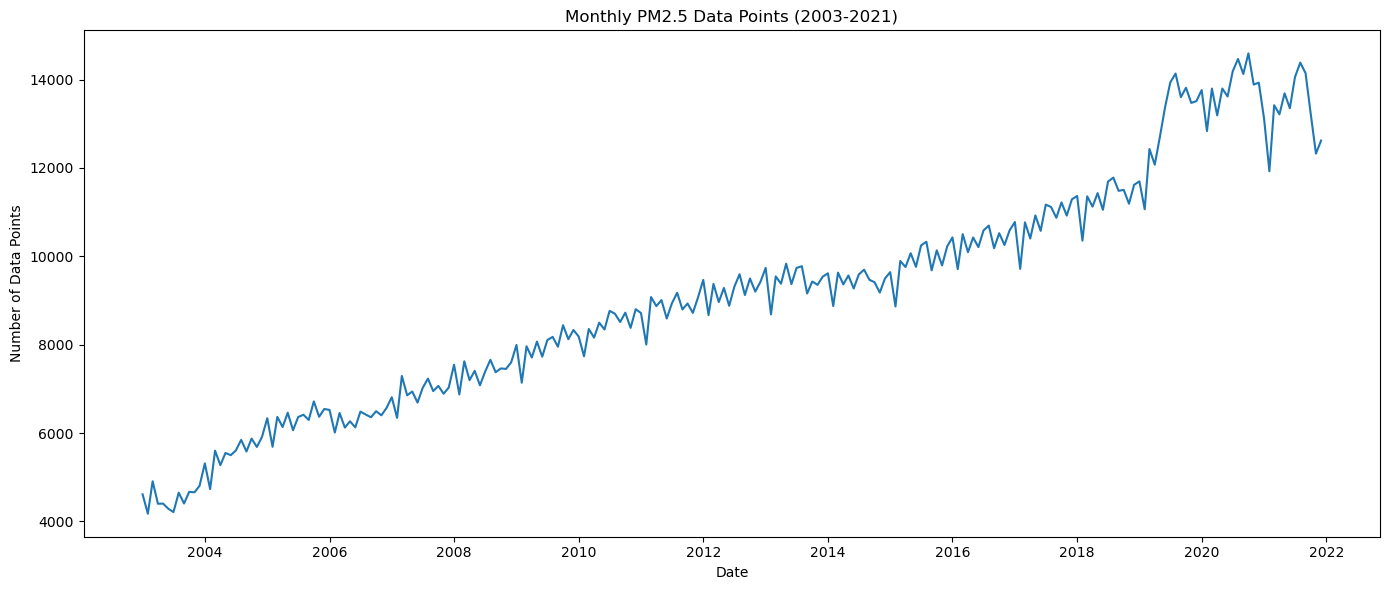

Total months: 228
Avg points per month: 9100


In [29]:
# Aggregate to monthly counts
monthly_counts = pm_filtered.groupby(pm_filtered['date_dt'].dt.to_period('M')).size()

# Convert period index to timestamp for plotting
monthly_counts.index = monthly_counts.index.to_timestamp()

# Create line plot
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly_counts.index, monthly_counts.values, linewidth=1.5)

ax.set_xlabel('Date')
ax.set_ylabel('Number of Data Points')
ax.set_title('Monthly PM2.5 Data Points (2003-2021)')

plt.tight_layout()
plt.show()

print(f"Total months: {len(monthly_counts)}")
print(f"Avg points per month: {monthly_counts.mean():.0f}")

In [33]:
50*365

18250